In [2]:
import pandas as pd
df = pd.read_csv("/Users/hemanth/sentinel/data/processed/logs_labeled.csv")
print(df["severity_label"].value_counts())
print(df["severity_label"].value_counts(normalize=True))

severity_label
LOW         2000
MEDIUM      1500
HIGH        1000
CRITICAL     500
Name: count, dtype: int64
severity_label
LOW         0.4
MEDIUM      0.3
HIGH        0.2
CRITICAL    0.1
Name: proportion, dtype: float64


In [3]:
print(df.groupby(["severity_label", "service_name"]).size().unstack())

service_name    api-gateway  auth-service  database  nginx  payment-service  \
severity_label                                                                
CRITICAL                 72            59        71     77              145   
HIGH                    142           145       278    158              152   
LOW                     267           482       241    490              260   
MEDIUM                  442           217       199    206              220   

service_name    user-service  
severity_label                
CRITICAL                  76  
HIGH                     125  
LOW                      260  
MEDIUM                   216  


In [4]:
print(df[["hour_of_day", "message_length", "service_encoded"]].describe())

       hour_of_day  message_length  service_encoded
count  5000.000000     5000.000000      5000.000000
mean     11.461400       69.488000         2.416600
std       7.001422       10.252067         1.679169
min       0.000000       47.000000         0.000000
25%       5.000000       62.000000         1.000000
50%      11.000000       69.000000         2.000000
75%      18.000000       77.000000         4.000000
max      23.000000      100.000000         5.000000


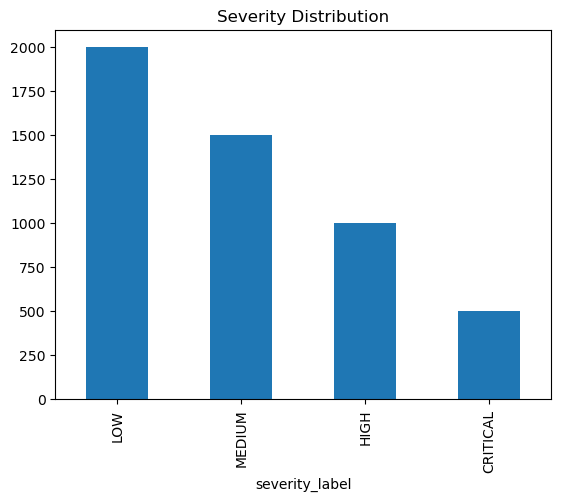

In [5]:
import matplotlib.pyplot as plt
df["severity_label"].value_counts().plot(kind="bar")
plt.title("Severity Distribution")
plt.show()

In [6]:
severity_map = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "CRITICAL": 3}
df["severity_encoded"] = df["severity_label"].map(severity_map)
print(df[["hour_of_day", "message_length", "service_encoded",
          "severity_encoded"]].corr())

                  hour_of_day  message_length  service_encoded  \
hour_of_day          1.000000        0.006906         0.006515   
message_length       0.006906        1.000000         0.176760   
service_encoded      0.006515        0.176760         1.000000   
severity_encoded     0.009028        0.495364         0.062418   

                  severity_encoded  
hour_of_day               0.009028  
message_length            0.495364  
service_encoded           0.062418  
severity_encoded          1.000000  
